##Library

In [ ]:
!unzip "archive (5).zip"

Archive:  archive (5).zip
replace ispu_dki1.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier as RFC

## Data Description
1. tanggal : Tanggal pencatatan kualitas udara
2. stasiun : Lokasi stasiun pemantauan
3. pm25 : Konsentrasi materi partikulat dengan diameter 2,5 mikrometer atau kurang (PM2.5), diukur dalam mikrogram per meter kubik (µg/m³).
4. pm10 : Konsentrasi materi partikulat dengan diameter 10 mikrometer atau kurang (PM10), diukur dalam mikrogram per meter kubik (µg/m³).
5. so2 : Konsentrasi sulfur dioksida (SO2), diukur dalam bagian per juta (ppm).
6. co : Konsentrasi karbon monoksida, diukur dalam bagian per juta (ppm).
7. o3 : Konsentrasi ozon (O3), diukur dalam bagian per juta (ppm).
8. no2 : Konsentrasi nitrogen dioksida (NO2), diukur dalam bagian per juta (ppm).
9. max : Nilai maksimum yang tercatat di antara polutan untuk tanggal dan stasiun tertentu. Nilai ini mewakili konsentrasi tertinggi di antara PM25, PM10, SO2, CO, O3, dan NO2.
10. critical: Polutan yang mempunyai konsentrasi tertinggi pada tanggal dan stasiun tersebut.
11. category : Kategori kualitas udara berdasarkan nilai 'maks' yang menggambarkan tingkat kualitas udara.

## Extract Data

In [ ]:
df_dki_all = pd.read_csv("ispu_dki_all.csv")

In [ ]:
df_dki_all

,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK
...,...,...,...,...,...,...,...,...,...,...,...
5533,2025-02-24,DKI3 (Jagakarsa),70.0,45.0,52.0,18.0,19.0,40.0,70.0,PM25,SEDANG
5534,2025-02-25,DKI5 (Kebon Jeruk),75.0,18.0,28.0,13.0,25.0,4.0,75.0,PM25,SEDANG
5535,2025-02-26,DKI3 (Jagakarsa),65.0,46.0,57.0,11.0,11.0,51.0,65.0,PM25,SEDANG
5536,2025-02-27,DKI5 (Kebon Jeruk),111.0,29.0,24.0,21.0,34.0,8.0,111.0,PM25,TIDAK SEHAT


## Assessing Data

In [ ]:
df_dki_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   5538 non-null   object 
 1   stasiun   5537 non-null   object 
 2   pm25      1516 non-null   float64
 3   pm10      5223 non-null   float64
 4   so2       5408 non-null   float64
 5   co        5450 non-null   float64
 6   o3        5434 non-null   float64
 7   no2       5432 non-null   float64
 8   max       5537 non-null   float64
 9   critical  5534 non-null   object 
 10  categori  5538 non-null   object 
dtypes: float64(7), object(4)
memory usage: 476.1+ KB


In [ ]:
df_dki_all.duplicated().sum()

np.int64(0)

Tidak memiliki data duplikat

In [ ]:
df_dki_all.isnull().sum()

,0
tanggal,0
stasiun,1
pm25,4022
pm10,315
so2,130
co,88
o3,104
no2,106
max,1
critical,4


In [ ]:
df_dki_all.isna().sum()

,0
tanggal,0
stasiun,1
pm25,4022
pm10,315
so2,130
co,88
o3,104
no2,106
max,1
critical,4


Terdapat banyak missing value

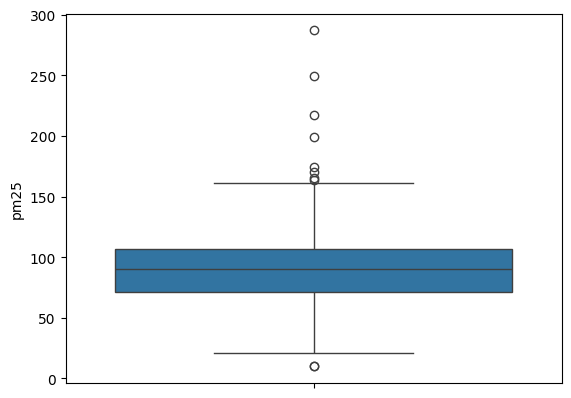

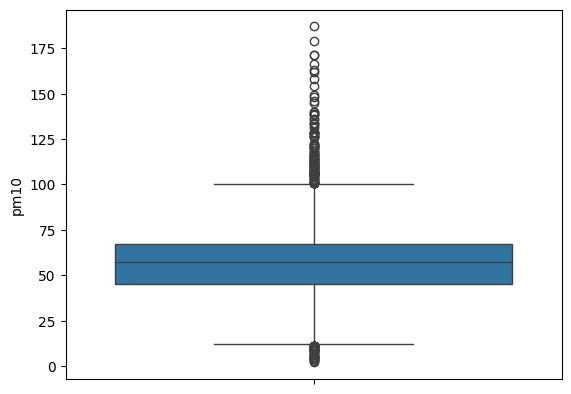

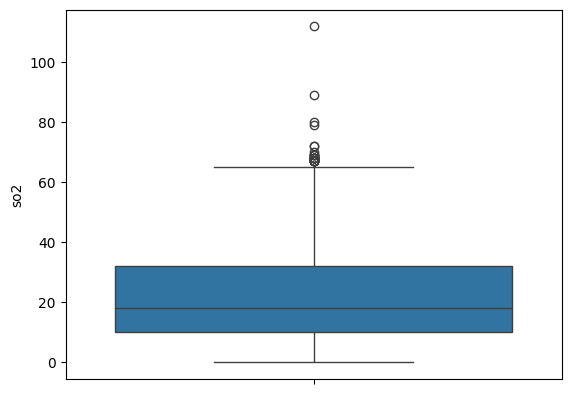

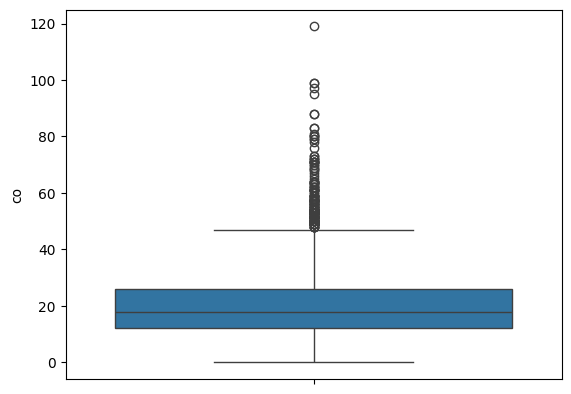

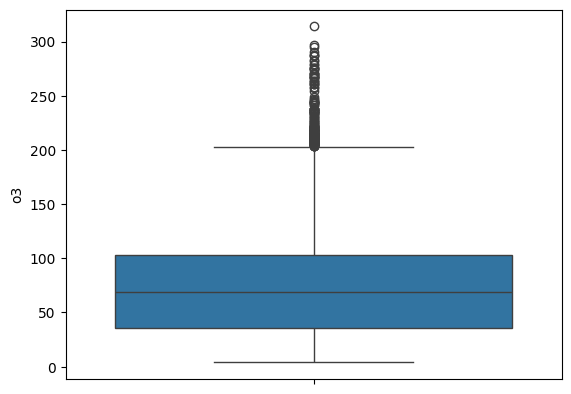

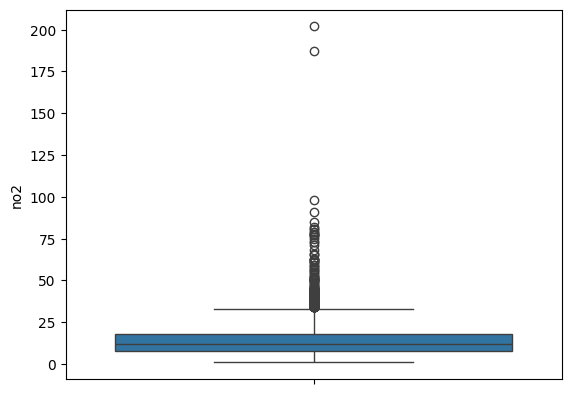

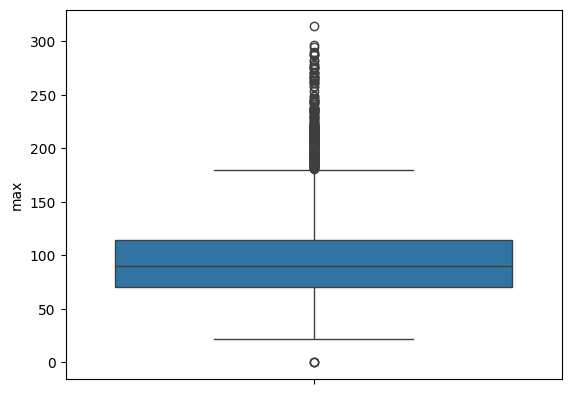

In [ ]:
for col in df_dki_all.columns:
  if df_dki_all[col].dtype in [np.float64]:
    sns.boxplot(df_dki_all[col])
    plt.show()

Gambar di atas merupakan boxplot dari kolom-kolom numerik seperti pm25 dan lain-lain. Data pada dataset ini memiliki banyak outlier. Tidak hanya pada kolom itu saja, kolom-kolom lainnya seperti pm10, so2, co, o3, no2, dan max memiliki outlier juga.

## Cleaning Data

In [ ]:
df_dki_all = df_dki_all.dropna()

In [ ]:
df_dki_all.isnull().sum()

,0
tanggal,0
stasiun,0
pm25,0
pm10,0
so2,0
co,0
o3,0
no2,0
max,0
critical,0


In [ ]:
df_dki_all.reset_index(inplace=True)

In [ ]:
df_dki_all.drop('index', axis=1, inplace=True)

<ipython-input-77-1c10e7cd7e65>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dki_all.drop('index', axis=1, inplace=True)


In [ ]:
stasiun_list = {
    'DKI1 (Bunderan HI)': 'Bunderan HI',
    'DKI2 (Kelapa Gading)': 'Kelapa Gading',
    'DKI3 (Jagakarsa)': 'Jagakarsa',
    'DKI4 (Lubang Buaya)': 'Lubang Buaya',
    'DKI5 (Kebon Jeruk)': 'Kebon Jeruk'
}

df_dki_all['stasiun'] = df_dki_all['stasiun'].replace(stasiun_list)

<ipython-input-78-5bdd81e136fc>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dki_all['stasiun'] = df_dki_all['stasiun'].replace(stasiun_list)


In [ ]:
df_dki_all['categori'] = df_dki_all['categori'].str.title()

<ipython-input-79-ddaed236e53b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dki_all['categori'] = df_dki_all['categori'].str.title()


In [ ]:
df_dki_all

,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2021-01-01,Kelapa Gading,58.0,38.0,2.0,11.0,65.0,6.0,65.0,O3,Sedang
1,2021-01-02,Jagakarsa,86.0,58.0,15.0,22.0,38.0,5.0,86.0,PM25,Sedang
2,2021-01-03,Jagakarsa,93.0,64.0,14.0,20.0,35.0,5.0,93.0,PM25,Sedang
3,2021-01-05,Jagakarsa,89.0,59.0,15.0,19.0,42.0,7.0,89.0,PM25,Sedang
4,2021-01-09,Kelapa Gading,67.0,51.0,12.0,27.0,80.0,12.0,80.0,O3,Sedang
...,...,...,...,...,...,...,...,...,...,...,...
1255,2025-02-24,Jagakarsa,70.0,45.0,52.0,18.0,19.0,40.0,70.0,PM25,Sedang
1256,2025-02-25,Kebon Jeruk,75.0,18.0,28.0,13.0,25.0,4.0,75.0,PM25,Sedang
1257,2025-02-26,Jagakarsa,65.0,46.0,57.0,11.0,11.0,51.0,65.0,PM25,Sedang
1258,2025-02-27,Kebon Jeruk,111.0,29.0,24.0,21.0,34.0,8.0,111.0,PM25,Tidak Sehat


In [ ]:
def cap_outliers(df, column):
    if df[column].dtype in [np.float64]:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        batas_bawah = Q1 - 1.5 * IQR
        batas_atas = Q3 + 1.5 * IQR
        kond_kurang_dari = df[column] < batas_bawah
        kond_lebih_dari = df[column] > batas_atas
        df[column] = df[column].mask(cond=kond_lebih_dari, other=batas_atas, axis=0)
        df[column] = df[column].mask(cond=kond_kurang_dari, other=batas_bawah, axis=0)
    return df

<ipython-input-81-7d8011bdbba1>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_lebih_dari, other=batas_atas, axis=0)
<ipython-input-81-7d8011bdbba1>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_kurang_dari, other=batas_bawah, axis=0)


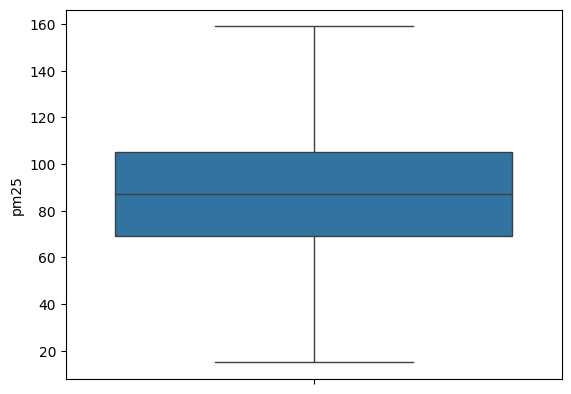

<ipython-input-81-7d8011bdbba1>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_lebih_dari, other=batas_atas, axis=0)
<ipython-input-81-7d8011bdbba1>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_kurang_dari, other=batas_bawah, axis=0)


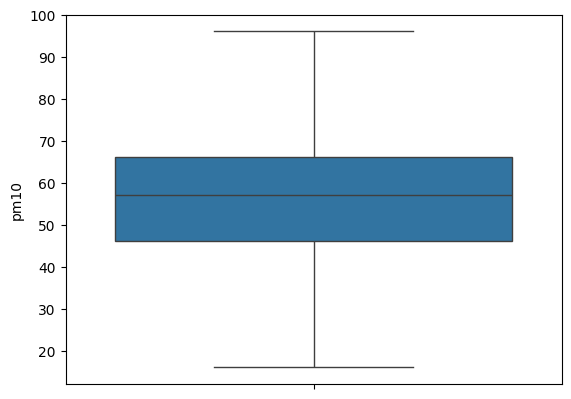

<ipython-input-81-7d8011bdbba1>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_lebih_dari, other=batas_atas, axis=0)
<ipython-input-81-7d8011bdbba1>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_kurang_dari, other=batas_bawah, axis=0)


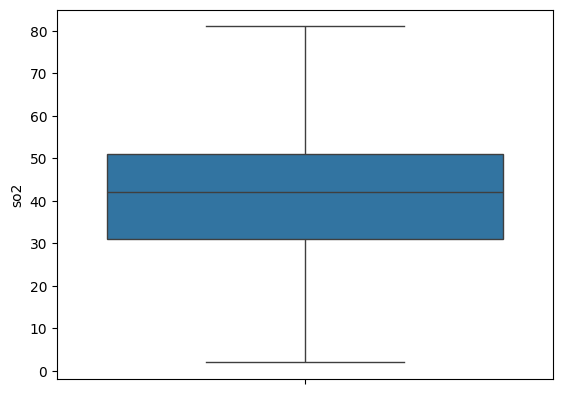

<ipython-input-81-7d8011bdbba1>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_lebih_dari, other=batas_atas, axis=0)
<ipython-input-81-7d8011bdbba1>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_kurang_dari, other=batas_bawah, axis=0)


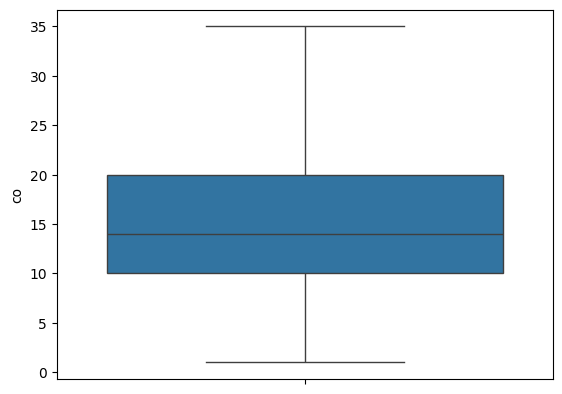

<ipython-input-81-7d8011bdbba1>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_lebih_dari, other=batas_atas, axis=0)
<ipython-input-81-7d8011bdbba1>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_kurang_dari, other=batas_bawah, axis=0)


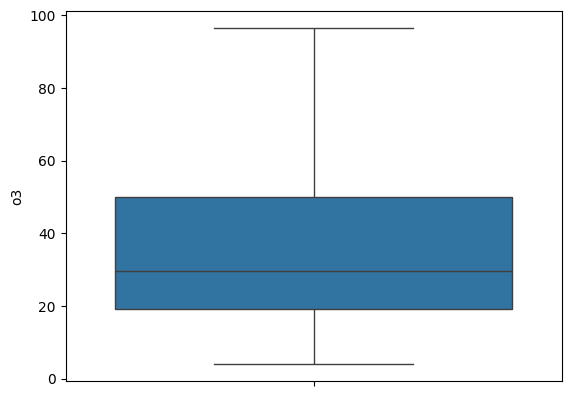

<ipython-input-81-7d8011bdbba1>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_lebih_dari, other=batas_atas, axis=0)
<ipython-input-81-7d8011bdbba1>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_kurang_dari, other=batas_bawah, axis=0)


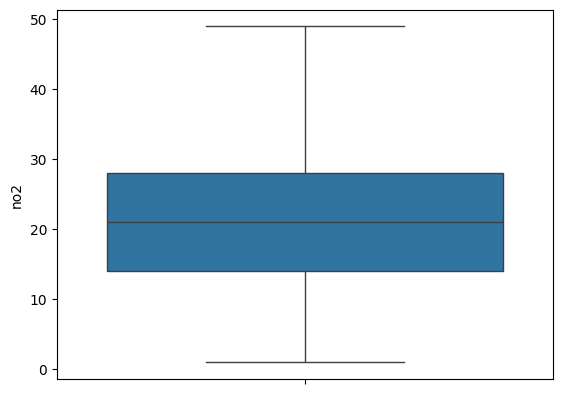

<ipython-input-81-7d8011bdbba1>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_lebih_dari, other=batas_atas, axis=0)
<ipython-input-81-7d8011bdbba1>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].mask(cond=kond_kurang_dari, other=batas_bawah, axis=0)


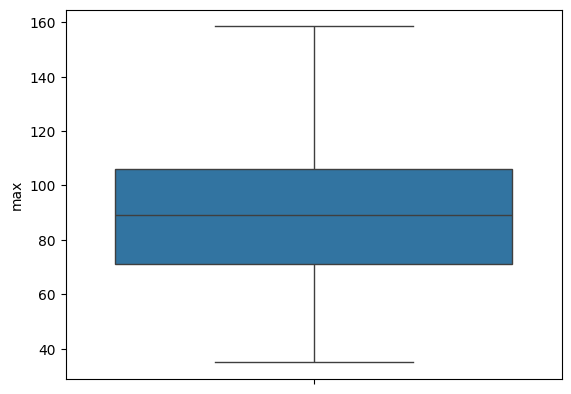

In [ ]:
for col in df_dki_all.columns:
  if df_dki_all[col].dtype in [np.float64]:
    df_dki_all = cap_outliers(df_dki_all, col)
    sns.boxplot(df_dki_all[col])
    plt.show()

## EDA

<Axes: xlabel='stasiun'>

<Figure size 1600x1200 with 0 Axes>

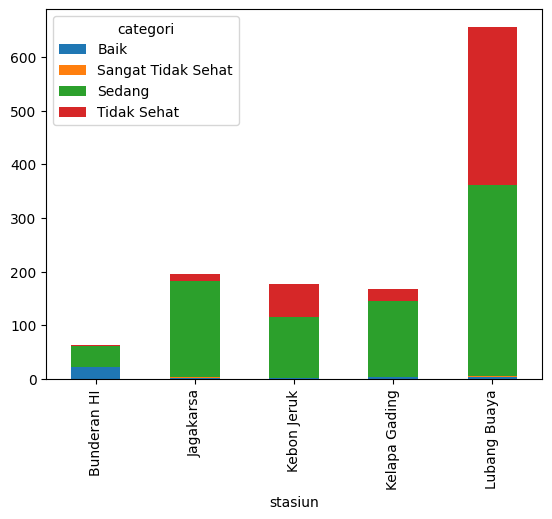

In [ ]:
plt.figure(figsize=(16,12))
stategori = df_dki_all.groupby('stasiun')['categori'].value_counts().unstack()
stategori.plot(kind='bar', stacked=True)

Dari bar chart ini, dapat dilihat kualitas udara berdasarkan stasiun. Stasiun lubang buaya memiliki kualitas udara yang tidak sehat terbanyak diantara stasiun lainnya. Meskipun semua stasiun rata-rata memiliki kualitas udara yang sedang, tidak ada satu kota pun yang memiliki kualitas udara yang sangat baik. Hal ini cukup memprihatinkan.

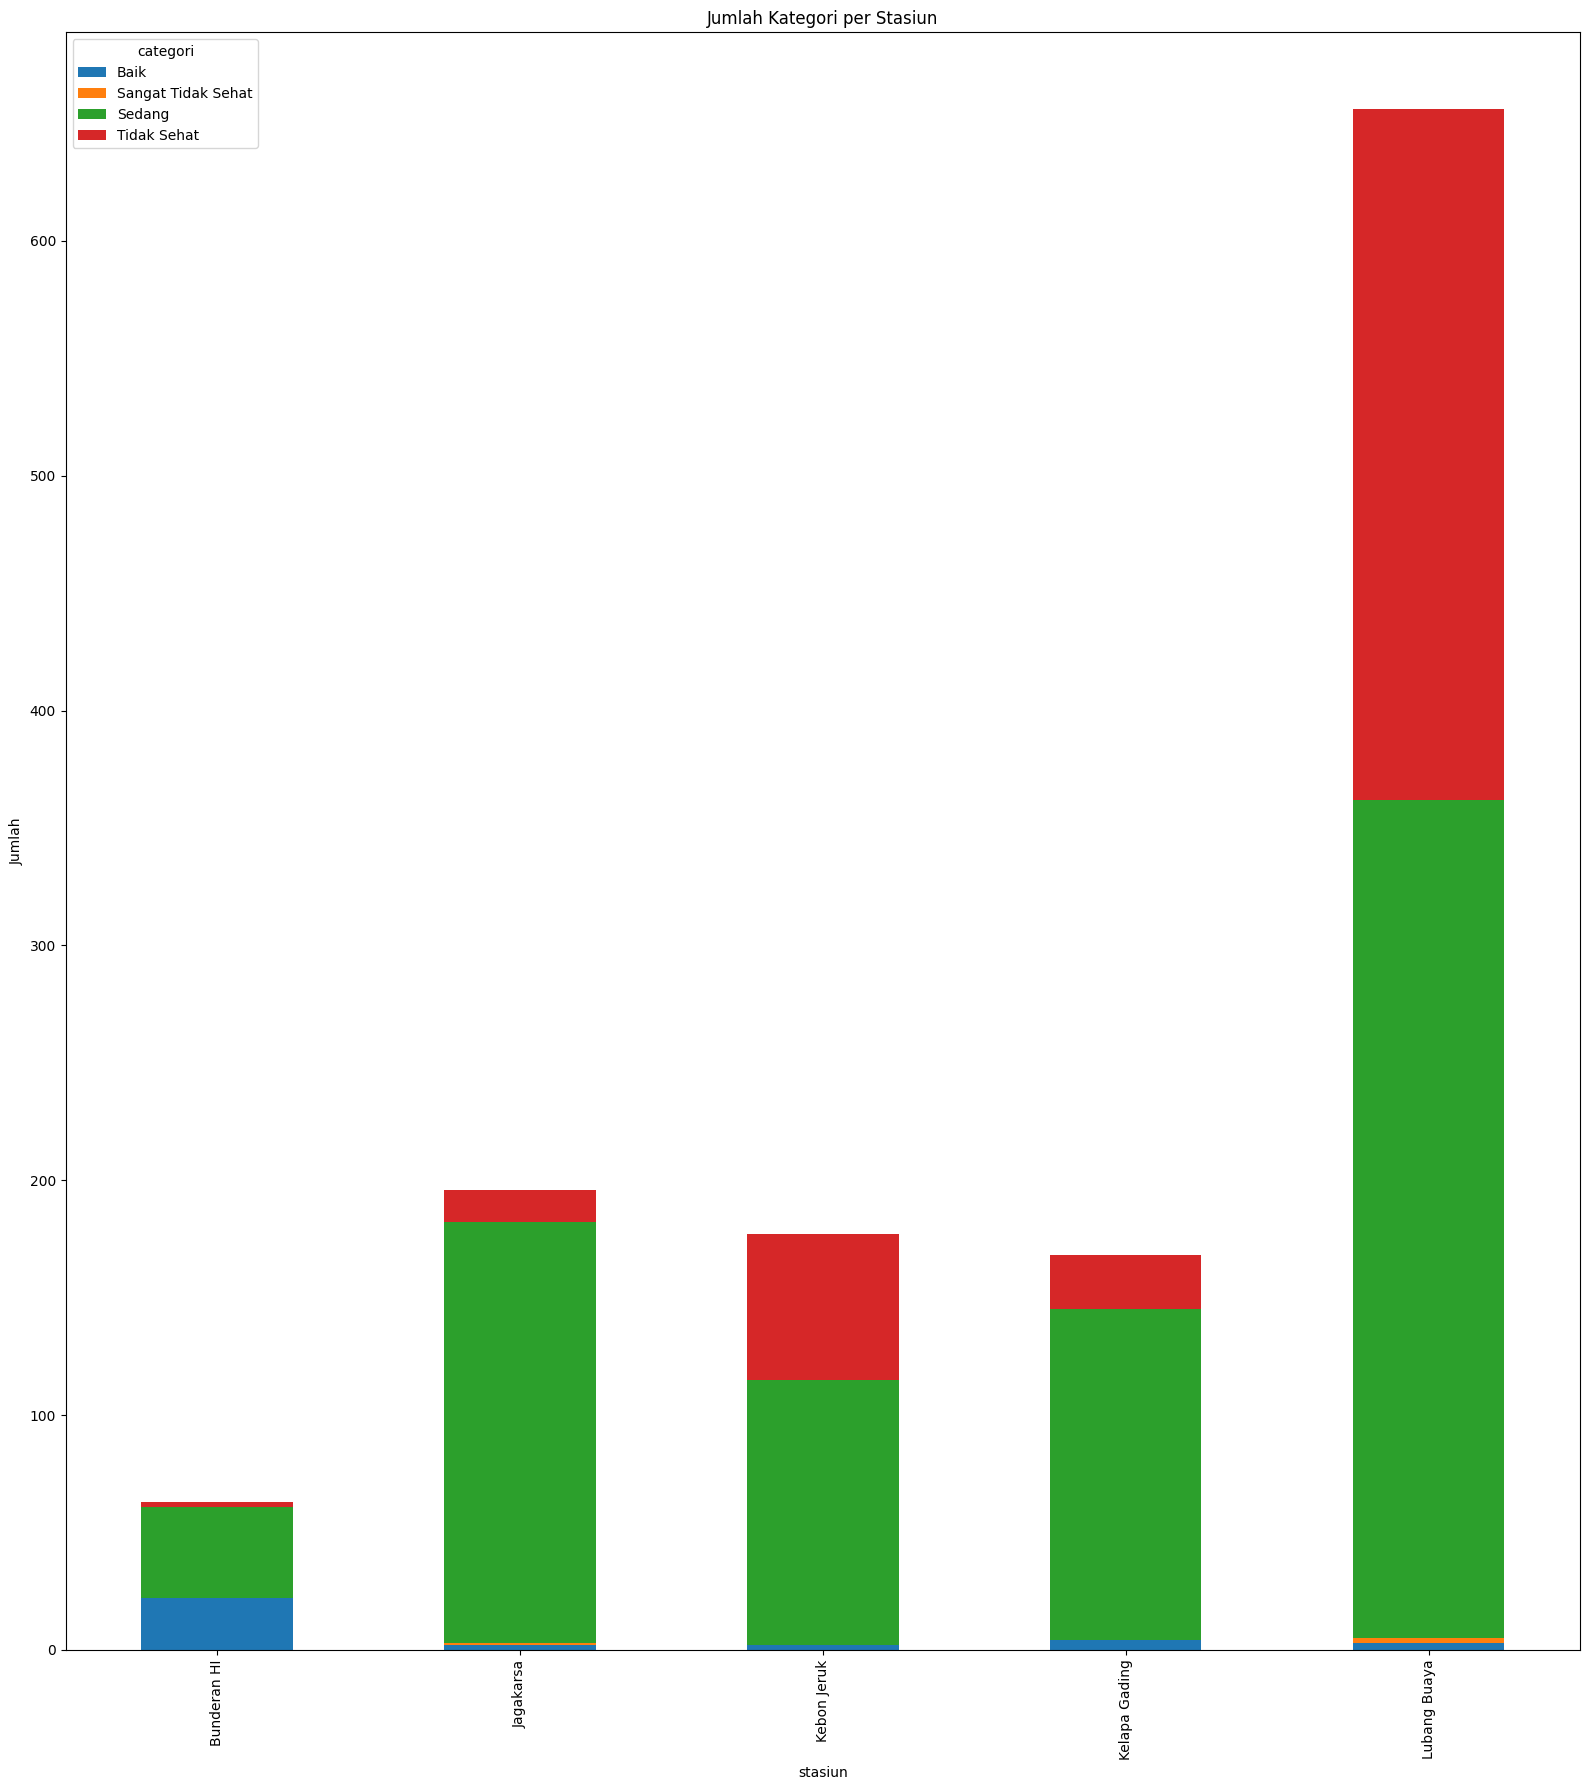

In [ ]:
fig, ax = plt.subplots(figsize=(16, 18))

stategori = df_dki_all.groupby('stasiun')['categori'].value_counts().unstack()
stategori.plot(kind='bar', stacked=True, ax=ax)
ax.set_ylabel('Jumlah')
ax.set_title('Jumlah Kategori per Stasiun')

plt.tight_layout()
plt.show()

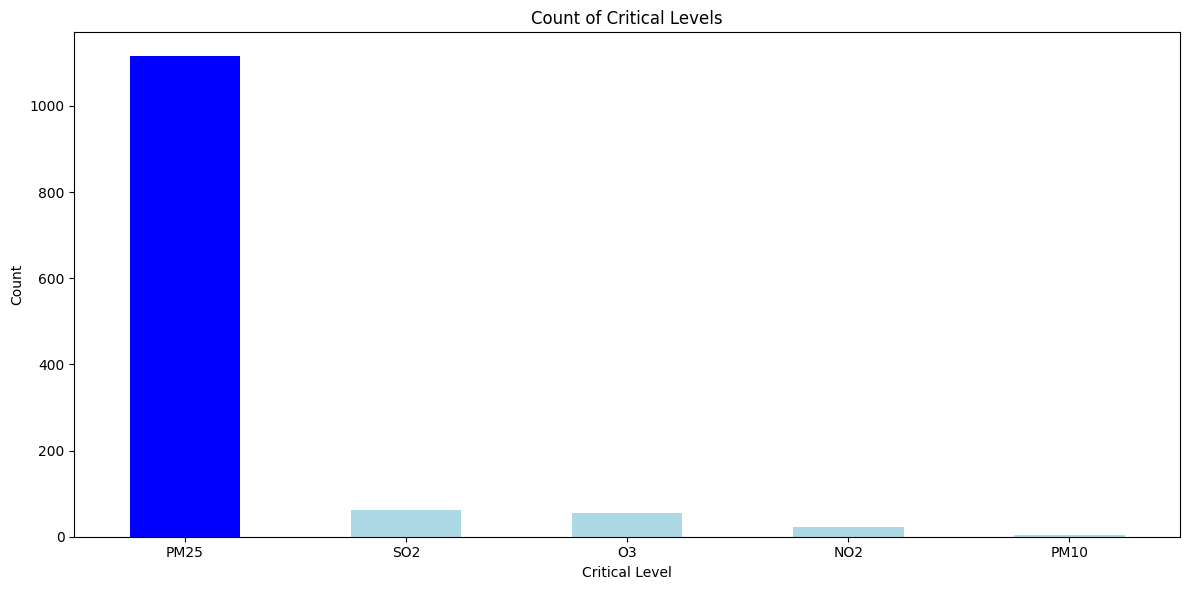

In [ ]:
plt.figure(figsize=(12, 6))

cnt_critical = df_dki_all['critical'].value_counts()

colors = ['blue' if count == cnt_critical.max() else 'lightblue' for count in cnt_critical]

cnt_critical.plot(kind='bar', color=colors)

plt.xlabel('Critical Level')
plt.ylabel('Count')
plt.title('Count of Critical Levels')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Polutan PM2.5 merupakan polutan yang paling sering menyentuh titik kritis. Terdapat 1000 data lebih yang menyatakan bahwa polutan PM2.5 mencapai titik kritis.

In [ ]:
le = LabelEncoder()
corr_df = df_dki_all.copy()
cat_columns = ['stasiun', 'critical', 'categori']
for col in cat_columns:
    corr_df[col] = le.fit_transform(corr_df[col])

corr_df

,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2021-01-01,3,58.0,38.0,2.0,11.0,65.0,6.0,65.0,1,2
1,2021-01-02,1,86.0,58.0,15.0,22.0,38.0,5.0,86.0,3,2
2,2021-01-03,1,93.0,64.0,14.0,20.0,35.0,5.0,93.0,3,2
3,2021-01-05,1,89.0,59.0,15.0,19.0,42.0,7.0,89.0,3,2
4,2021-01-09,3,67.0,51.0,12.0,27.0,80.0,12.0,80.0,1,2
...,...,...,...,...,...,...,...,...,...,...,...
1255,2025-02-24,1,70.0,45.0,52.0,18.0,19.0,40.0,70.0,3,2
1256,2025-02-25,2,75.0,18.0,28.0,13.0,25.0,4.0,75.0,3,2
1257,2025-02-26,1,65.0,46.0,57.0,11.0,11.0,49.0,65.0,3,2
1258,2025-02-27,2,111.0,29.0,24.0,21.0,34.0,8.0,111.0,3,3


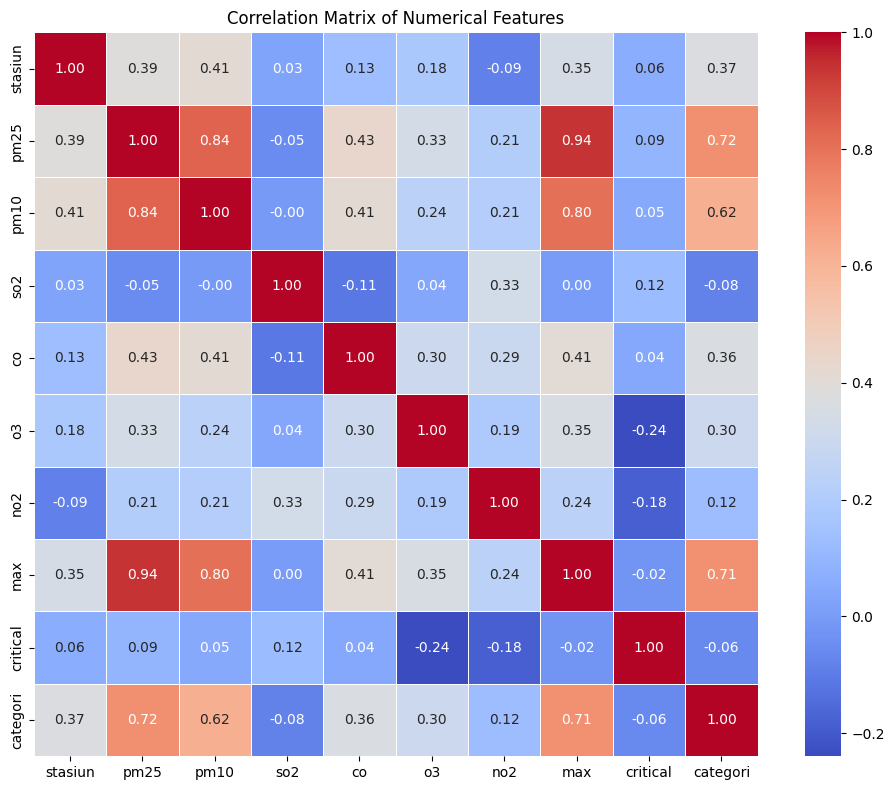

In [ ]:
numeric_df = corr_df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

Dari correlation matrix ini, kolom pm25, pm10, dan max memiliki korelasi kuat terhadap label categori, yang menjadikan bahwa ketiga kolom tersebut sangat mungkin relevan untuk model klasifikasi. Kolom stasiun terhadap pm25/pm10/categori juga cukup memiliki hubungan yang menandakan bahwa stasiun juga memiliki peran terhadap kategori kualitas udara.

In [ ]:
numerical_col = [col for col in df_dki_all.columns if df_dki_all[col].dtype == 'float64']
needed_col = ['tanggal'] + numerical_col
df_num = df_dki_all[needed_col]

In [ ]:
df_num

,tanggal,pm25,pm10,so2,co,o3,no2,max
0,2021-01-01,58.0,38.0,2.0,11.0,65.0,6.0,65.0
1,2021-01-02,86.0,58.0,15.0,22.0,38.0,5.0,86.0
2,2021-01-03,93.0,64.0,14.0,20.0,35.0,5.0,93.0
3,2021-01-05,89.0,59.0,15.0,19.0,42.0,7.0,89.0
4,2021-01-09,67.0,51.0,12.0,27.0,80.0,12.0,80.0
...,...,...,...,...,...,...,...,...
1255,2025-02-24,70.0,45.0,52.0,18.0,19.0,40.0,70.0
1256,2025-02-25,75.0,18.0,28.0,13.0,25.0,4.0,75.0
1257,2025-02-26,65.0,46.0,57.0,11.0,11.0,49.0,65.0
1258,2025-02-27,111.0,29.0,24.0,21.0,34.0,8.0,111.0


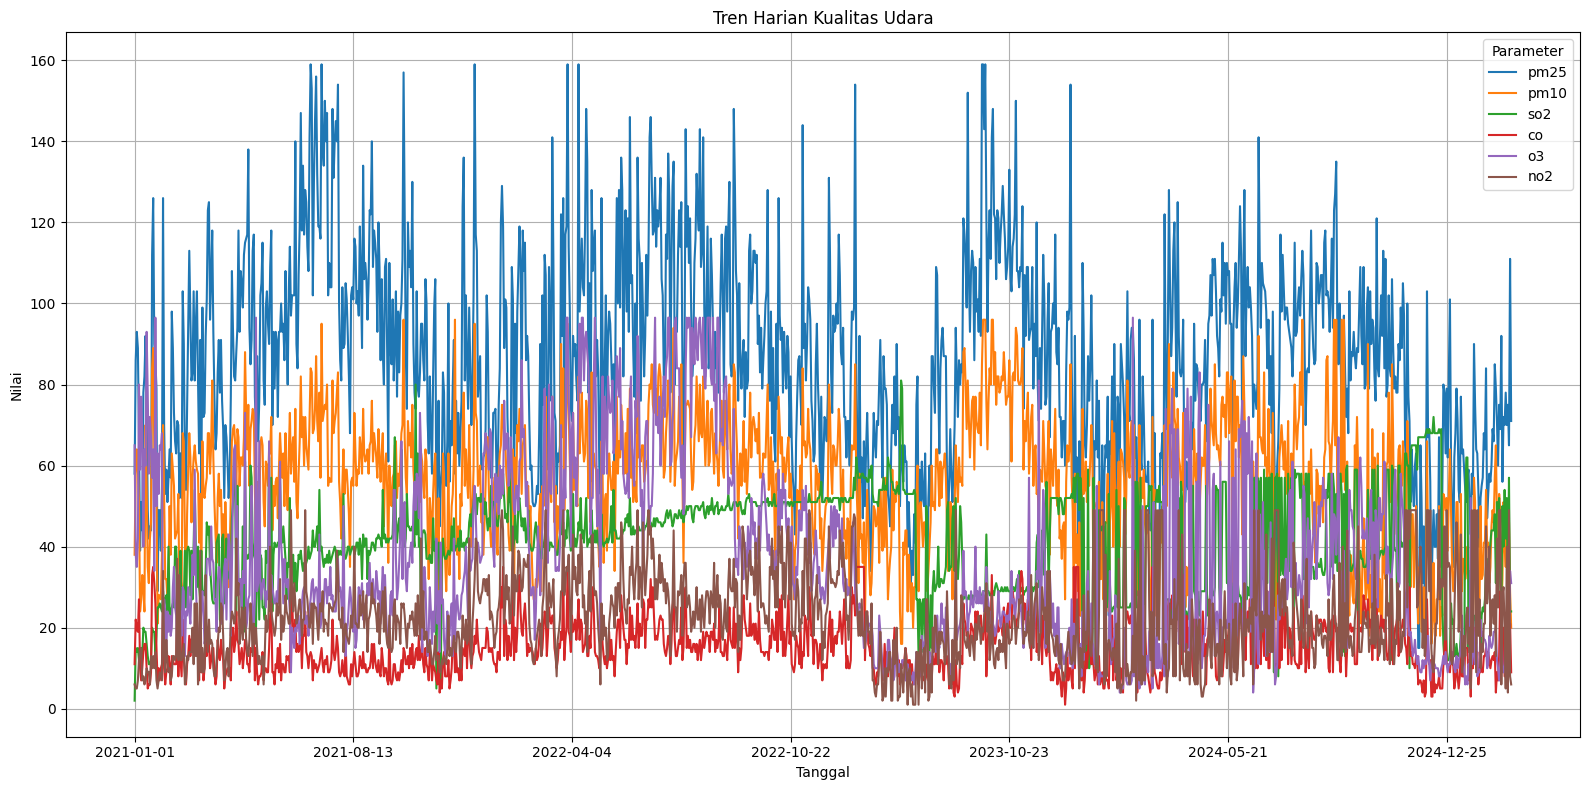

In [ ]:
df_num = df_num.drop(columns='max')
df_num.set_index('tanggal', inplace=True)

plt.figure(figsize=(16, 8))
df_num.plot(ax=plt.gca())

plt.title('Tren Harian Kualitas Udara')
plt.xlabel('Tanggal')
plt.ylabel('Nilai')
plt.legend(title='Parameter')
plt.grid(True)
plt.tight_layout()
plt.show()

Dilihat dari line chart ini, PM2.5 merupakan polutan paling fluktuatif dan palin sering melonjak tinggi. Apabila dilihat dari pola Polutan seperti PM2.5 dan PM10, sangat memungkinkan bahwa pada 2025 akan mengalami kenaikan lagi dan mungkin akan mencapai puncak pada pertengahan 2025 seperti pada bulan Okteber 2023.


## Data Preprocessing

In [ ]:
df_dki_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   1260 non-null   object 
 1   stasiun   1260 non-null   object 
 2   pm25      1260 non-null   float64
 3   pm10      1260 non-null   float64
 4   so2       1260 non-null   float64
 5   co        1260 non-null   float64
 6   o3        1260 non-null   float64
 7   no2       1260 non-null   float64
 8   max       1260 non-null   float64
 9   critical  1260 non-null   object 
 10  categori  1260 non-null   object 
dtypes: float64(7), object(4)
memory usage: 108.4+ KB


In [ ]:
df_dki_all = df_dki_all.drop(columns=['tanggal','max','critical'])

Kolom tanggal hanya menunjukkan kapan data diambil sehingga tidak relevan untuk digunakan, sehingga kolom ini di drop. Kolom seperti max di drop karena meskipun kolom tersebut memiliki korelasi yang kuat dengan categori, kolom ini hanya memberitahu ulang nilai polutan mana yang memiliki nilai paling tinggi. Dengan adanya kolom max, ditakutkan model hanya melihat max dan mengabaikan kontribusi polutan lain. Kolom critical juga di drop karena kolom tersebut juga hanya berisi data dari nama polutan yang paling tinggi konsentrasinya.

In [ ]:
categorical_col = ['stasiun', 'categori']
for col in categorical_col:
    df_dki_all[col] = le.fit_transform(df_dki_all[col])

In [ ]:
df_dki_all['stasiun'] = df_dki_all['stasiun'].astype('float64')

Melakukan label encoder untuk kolom stasiun dan categori

In [ ]:
df_dki_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   stasiun   1260 non-null   float64
 1   pm25      1260 non-null   float64
 2   pm10      1260 non-null   float64
 3   so2       1260 non-null   float64
 4   co        1260 non-null   float64
 5   o3        1260 non-null   float64
 6   no2       1260 non-null   float64
 7   categori  1260 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 78.9 KB


In [ ]:
scaler = StandardScaler()

In [ ]:
numerical_col = [col for col in df_dki_all.columns if df_dki_all[col].dtype == 'float64']

In [ ]:
for col in numerical_col:
  df_dki_all[col] = scaler.fit_transform(df_dki_all[[col]])

Standarisasi semua kolom numerik pada data

## Data Splitting

In [ ]:
df_dki_all

,stasiun,pm25,pm10,so2,co,o3,no2,categori
0,0.061604,-1.159985,-1.109664,-3.039555,-0.661848,1.305596,-1.495559,2
1,-1.460385,-0.064054,0.121017,-2.027235,1.000568,0.094928,-1.586743,2
2,-1.460385,0.209929,0.490221,-2.105106,0.698310,-0.039590,-1.586743,2
3,-1.460385,0.053368,0.182551,-2.027235,0.547182,0.274286,-1.404375,2
4,0.061604,-0.807721,-0.309721,-2.260848,1.756211,1.978189,-0.948456,2
...,...,...,...,...,...,...,...,...
1255,-1.460385,-0.690300,-0.678926,0.853983,0.396053,-0.757023,1.604690,2
1256,-0.699390,-0.494598,-2.340345,-1.014916,-0.359590,-0.487986,-1.677926,2
1257,-1.460385,-0.886002,-0.617392,1.243336,-0.661848,-1.115739,2.425344,2
1258,-0.699390,0.914457,-1.663470,-1.326399,0.849439,-0.084430,-1.313191,3


In [ ]:
X = df_dki_all.drop(columns=['categori'])
y = df_dki_all['categori']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Membagi data 80% untuk train 20% untuk test

## Modeling

In [ ]:
rf = RFC()
rf.fit(X_train, y_train)

RandomForestClassifier()

Membangun model Random Forest Classifier

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

Membangun model Logistic Regression

## Evaluasi

In [ ]:
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
cm_rf = confusion_matrix(y_test, y_pred)

In [ ]:
print("RF Accuracy:", acc)
print("RF F1 Score:", f1)
print(classification_report(y_test, y_pred))

RF Accuracy: 0.9920634920634921
RF F1 Score: 0.9916796348168897
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           2       0.99      0.99      0.99       173
           3       0.99      1.00      0.99        76

    accuracy                           0.99       252
   macro avg       0.99      0.89      0.93       252
weighted avg       0.99      0.99      0.99       252



Akurasi model Random Forest pada data test adalah sebesar 0.99 begitu juga dengan F1-score.

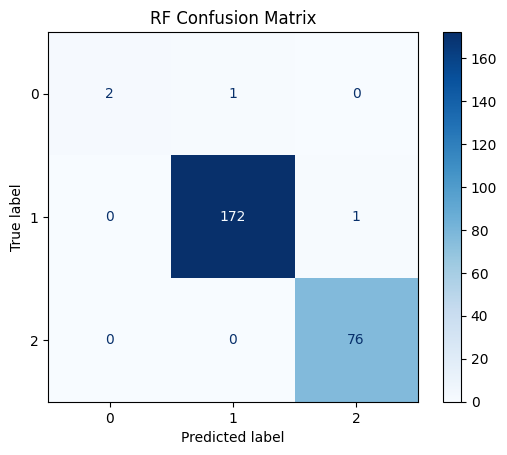

In [ ]:
conf_mat = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
conf_mat.plot(cmap='Blues')
plt.title("RF Confusion Matrix")
plt.grid(False)
plt.show()

Dilihat pada gambar metrik di atas, model ini hanya memiliki 2 kesalahan prediksi, yaitu label 1 yang diprediksi sebagai 0 sebanyak 1, dan label 2 yang diprediksi sebagai 1 sebanyak 1.

In [ ]:
y_pred = lr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
cm_lr = confusion_matrix(y_test, y_pred)

In [ ]:
print("LR Accuracy:", acc)
print("LR F1 Score:", f1)
print(classification_report(y_test, y_pred))

LR Accuracy: 0.9761904761904762
LR F1 Score: 0.9757963693965064
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           2       0.98      0.99      0.98       173
           3       0.97      0.96      0.97        76

    accuracy                           0.98       252
   macro avg       0.98      0.87      0.92       252
weighted avg       0.98      0.98      0.98       252



Akurasi model Logistic Regression pada data test adalah sebesar 0.97 begitu juga dengan F1-score.

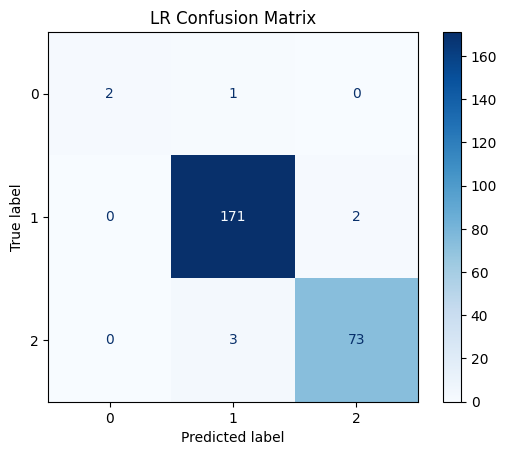

In [ ]:
conf_mat = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
conf_mat.plot(cmap='Blues')
plt.title("LR Confusion Matrix")
plt.grid(False)
plt.show()

Dilihat pada gambar metrik di atas, model ini memiliki lebih banyak kesalahan prediksi dibandingkan Random Forest, yaitu label 1 yang diprediksi sebagai 0 sebanyak 1 dan diprediksi sebagai 2 sebanyak 3, dan label 2 yang diprediksi sebagai 1 sebanyak 2.

In [ ]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

train_f1 = f1_score(y_train, train_pred, average='weighted')
test_f1 = f1_score(y_test, test_pred, average='weighted')

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("RF Train Accuracy:", train_acc)
print("RF Test Accuracy:", test_acc)
print("RF Train F1 Score:", train_f1)
print("RF Test F1 Score:", test_f1)

RF Train Accuracy: 1.0
RF Test Accuracy: 0.9920634920634921
RF Train F1 Score: 1.0
RF Test F1 Score: 0.9916796348168897


Model RF mengalami overfitting karena akurasi train lebih besar dibandingkan akurasi tes begitu juga dengan F1-scorenya.

In [ ]:
train_pred = lr.predict(X_train)
test_pred = lr.predict(X_test)

train_f1 = f1_score(y_train, train_pred, average='weighted')
test_f1 = f1_score(y_test, test_pred, average='weighted')

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("LR Train Accuracy:", train_acc)
print("LR Test Accuracy:", test_acc)
print("LR Train F1 Score:", train_f1)
print("LR Test F1 Score:", test_f1)

LR Train Accuracy: 0.9424603174603174
LR Test Accuracy: 0.9761904761904762
LR Train F1 Score: 0.9356552509581937
LR Test F1 Score: 0.9757963693965064


Model ini tidak mengalami overfitting, bahkan akurasi dan F1-score tes lebih tinggi dibandingkan dengan train.

## Tuning

In [ ]:
rf_param = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ['sqrt', 'log2']
}

lr_param = {
    "tol": [0.001, 0.05, 0.2],
    "class_weight": [None, 'balanced'],
    "max_iter": [100, 150, 200]
}

In [ ]:
rf_search = RandomizedSearchCV(rf, rf_param, n_iter=10, cv=3, random_state=42)
lr_search = RandomizedSearchCV(lr, lr_param, n_iter=10, cv=3, random_state=42)

rf_search.fit(X_train, y_train)
print("Best Random Forest Parameters:", rf_search.best_params_)

lr_search.fit(X_train, y_train)
print("Best Logistic Regression Parameters:", lr_search.best_params_)

Best Random Forest Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15}
Best Logistic Regression Parameters: {'tol': 0.001, 'max_iter': 100, 'class_weight': None}


## Evaluasi Ulang

In [ ]:
y_pred = rf_search.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
cm_rf = confusion_matrix(y_test, y_pred)

In [ ]:
print("RF Accuracy:", acc)
print("RF F1 Score:", f1)
print(classification_report(y_test, y_pred))

RF Accuracy: 0.9920634920634921
RF F1 Score: 0.9916796348168897
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           2       0.99      0.99      0.99       173
           3       0.99      1.00      0.99        76

    accuracy                           0.99       252
   macro avg       0.99      0.89      0.93       252
weighted avg       0.99      0.99      0.99       252



Setelah dilakukan tuning, akurasi model Random Forest pada data test tetap sebesar 0.99 begitu juga dengan F1-score.

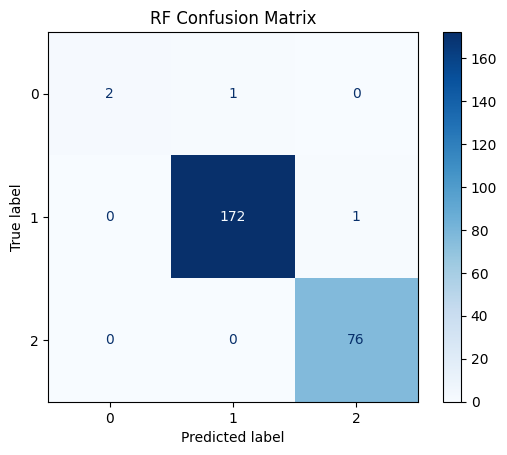

In [ ]:
conf_mat = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
conf_mat.plot(cmap='Blues')
plt.title("RF Confusion Matrix")
plt.grid(False)
plt.show()

Dilihat pada gambar metrik di atas, sama seperti sebelumnya, model ini hanya memiliki 2 kesalahan prediksi, yaitu label 1 yang diprediksi sebagai 0 sebanyak 1, dan label 2 yang diprediksi sebagai 1 sebanyak 1.

In [ ]:
y_pred = lr_search.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
cm_lr = confusion_matrix(y_test, y_pred)

In [ ]:
print("LR Accuracy:", acc)
print("LR F1 Score:", f1)
print(classification_report(y_test, y_pred))

LR Accuracy: 0.9801587301587301
LR F1 Score: 0.9797413623201591
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           2       0.98      0.99      0.99       173
           3       0.99      0.96      0.97        76

    accuracy                           0.98       252
   macro avg       0.99      0.87      0.92       252
weighted avg       0.98      0.98      0.98       252



Setelah dilakukan tuning, akurasi model Logistic Regression mengalami peningkatan sehingga menjadi 0.98 begitu juga dengan F1-score yang menjadi 0.979.

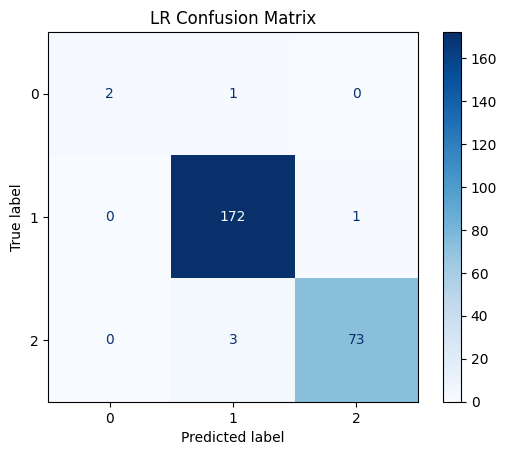

In [ ]:
conf_mat = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
conf_mat.plot(cmap='Blues')
plt.title("LR Confusion Matrix")
plt.grid(False)
plt.show()

Dilihat pada gambar metrik di atas, kesalahan yang dibuat model ini berkurang, yaitu label 1 yang diprediksi sebagai 0 sebanyak 1 dan diprediksi sebagai 2 sebanyak 3, dan label 2 yang diprediksi sebagai 1 sebanyak 1.

In [ ]:
train_pred = rf_search.predict(X_train)
test_pred = rf_search.predict(X_test)

train_f1 = f1_score(y_train, train_pred, average='weighted')
test_f1 = f1_score(y_test, test_pred, average='weighted')

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("RF Train Accuracy:", train_acc)
print("RF Test Accuracy:", test_acc)
print("RF Train F1 Score:", train_f1)
print("RF Test F1 Score:", test_f1)

RF Train Accuracy: 0.9920634920634921
RF Test Accuracy: 0.9920634920634921
RF Train F1 Score: 0.9905123225918774
RF Test F1 Score: 0.9916796348168897


Model lebih baik dari sebelumnya karena model ini tidak lagi menghasilkan akurasi dan F1-score train yang lebih tinggi dari pada tes. Hal ini menandakan bahwa model Random Forest ini tidak lagi overfitting.

In [ ]:
train_pred = lr_search.predict(X_train)
test_pred = lr_search.predict(X_test)

train_f1 = f1_score(y_train, train_pred, average='weighted')
test_f1 = f1_score(y_test, test_pred, average='weighted')

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("LR Train Accuracy:", train_acc)
print("LR Test Accuracy:", test_acc)
print("LR Train F1 Score:", train_f1)
print("LR Test F1 Score:", test_f1)

LR Train Accuracy: 0.9424603174603174
LR Test Accuracy: 0.9801587301587301
LR Train F1 Score: 0.9362806614769447
LR Test F1 Score: 0.9797413623201591


Model mengalami peningkatan baik secara akurasi dan F1-Score. Model ini juga tidak overfitting.

## Kesimpulan

Kesimpulannya, dari kedua model yang sudah dibuat, model terbaik yang akan dipilih adalah Random Forest karena model Random Forest memiliki performa yang lebih baik dibandingkan Logistic Regression dan model ini tidak lagi overfitting setelah tuning.